In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("vendas.csv")

In [3]:
df.head()

,id_venda,data_venda,cliente,idade_cliente,categoria,produto,regiao,quantidade,valor_venda,cancelado
0,1,2025-01-29,Daniela,32.0,Acessórios,Carregador,Norte,9,3720.67,Sim
1,2,2025-04-19,Daniela,32.0,Acessorios,Fone,Sul,4,197.50,Não
2,3,04-25-2025,Ana,66.0,Informatica,Notebook,Sudeste,6,1427.04,Não
3,4,25/02/2025,Gustavo,24.0,Informatica,Mouse,Centro-Oeste,10,555.94,Não
4,5,04-28-2025,Gustavo,23.0,Eletrônicos,Smartwatch,Sul,6,667.89,Sim


In [4]:
df.shape

(100, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id_venda       100 non-null    int64  
 1   data_venda     100 non-null    object 
 2   cliente        100 non-null    object 
 3   idade_cliente  97 non-null     float64
 4   categoria      97 non-null     object 
 5   produto        100 non-null    object 
 6   regiao         100 non-null    object 
 7   quantidade     100 non-null    int64  
 8   valor_venda    99 non-null     float64
 9   cancelado      100 non-null    object 
dtypes: float64(2), int64(2), object(6)
memory usage: 7.9+ KB


In [6]:
df.describe()

,id_venda,idade_cliente,quantidade,valor_venda
count,100.00000,97.000000,100.000000,99.000000
mean,48.94000,44.474227,5.750000,3716.713333
std,28.60558,14.671467,2.675648,7201.305434
min,1.00000,18.000000,1.000000,-150.000000
25%,24.75000,32.000000,4.000000,1385.155000
50%,48.50000,44.000000,6.000000,2554.510000
75%,73.25000,58.000000,8.000000,4070.495000
max,100.00000,68.000000,10.000000,50000.000000


In [7]:
#Produtos mais vendidos
df["categoria"].value_counts()

,count
categoria,
Celulares,21
Acessorios,18
Acessórios,16
Eletrônicos,16
Informatica,15
Informática,11


In [8]:
#Percentual de produtos vendidos
df["categoria"].value_counts(normalize=True) * 100

,proportion
categoria,
Celulares,21.649485
Acessorios,18.556701
Acessórios,16.494845
Eletrônicos,16.494845
Informatica,15.463918
Informática,11.340206


In [9]:
#contagem de dados ausentes
df.isnull().sum()

,0
id_venda,0
data_venda,0
cliente,0
idade_cliente,3
categoria,3
produto,0
regiao,0
quantidade,0
valor_venda,1
cancelado,0


In [10]:
#percentual de dados ausentes
(df.isnull().mean() * 100).round(2)

,0
id_venda,0.0
data_venda,0.0
cliente,0.0
idade_cliente,3.0
categoria,3.0
produto,0.0
regiao,0.0
quantidade,0.0
valor_venda,1.0
cancelado,0.0


In [29]:
#remover registros
df = df.dropna().copy()

In [13]:
#preencher valores
df["valor_venda"] = df["valor_venda"].fillna(df["valor_venda"].median())

In [14]:
df.isnull().sum()

,0
id_venda,0
data_venda,0
cliente,0
idade_cliente,0
categoria,0
produto,0
regiao,0
quantidade,0
valor_venda,0
cancelado,0


In [15]:
df.describe()

,id_venda,idade_cliente,quantidade,valor_venda
count,93.000000,93.000000,93.000000,93.000000
mean,50.182796,44.225806,5.774194,3767.134946
std,28.441758,14.566287,2.687042,7426.949707
min,1.000000,18.000000,1.000000,-150.000000
25%,26.000000,31.000000,4.000000,1361.160000
50%,50.000000,44.000000,6.000000,2392.270000
75%,74.000000,57.000000,8.000000,4172.810000
max,100.000000,68.000000,10.000000,50000.000000


In [16]:
df.duplicated().sum()

np.int64(1)

In [30]:
df = df.drop_duplicates().copy()

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 92 entries, 0 to 99
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id_venda       92 non-null     int64  
 1   data_venda     92 non-null     object 
 2   cliente        92 non-null     object 
 3   idade_cliente  92 non-null     float64
 4   categoria      92 non-null     object 
 5   produto        92 non-null     object 
 6   regiao         92 non-null     object 
 7   quantidade     92 non-null     int64  
 8   valor_venda    92 non-null     float64
 9   cancelado      92 non-null     object 
dtypes: float64(2), int64(2), object(6)
memory usage: 7.9+ KB


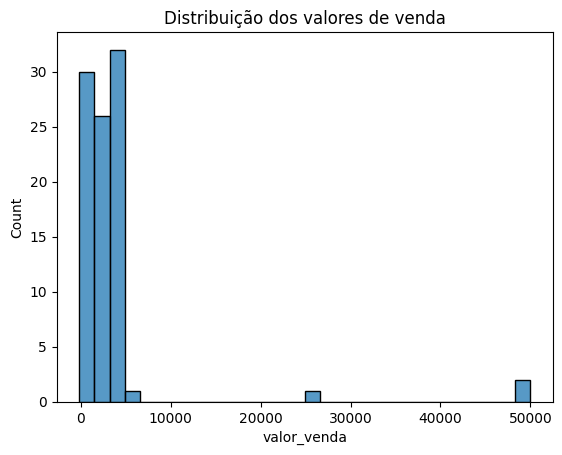

In [19]:
sns.histplot(df["valor_venda"], bins=30)
plt.title("Distribuição dos valores de venda")
plt.show()

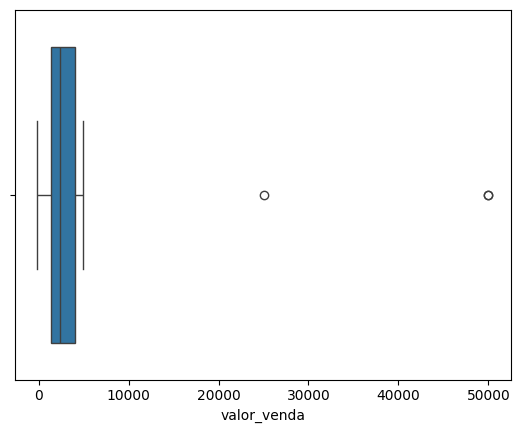

In [20]:
sns.boxplot(x=df["valor_venda"])
plt.show()

In [21]:
df.corr(numeric_only=True)

,id_venda,idade_cliente,quantidade,valor_venda
id_venda,1.000000,0.010268,-0.099015,0.001637
idade_cliente,0.010268,1.000000,0.008058,0.064715
quantidade,-0.099015,0.008058,1.000000,-0.010369
valor_venda,0.001637,0.064715,-0.010369,1.000000


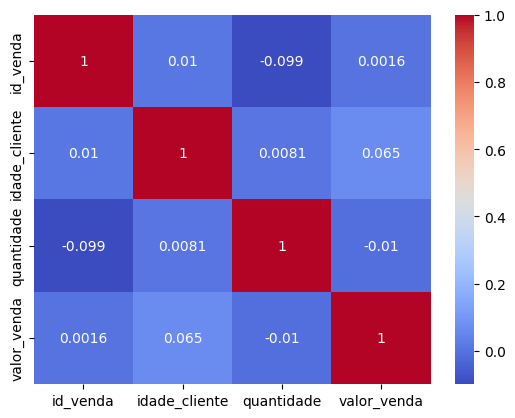

In [22]:
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.show()

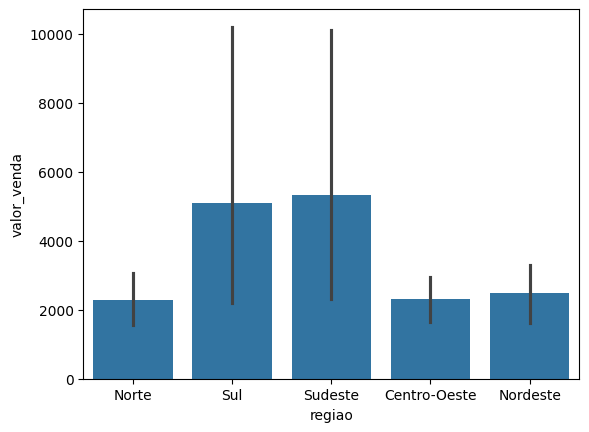

In [23]:
#Faturamento por região

sns.barplot(
    data=df,
    x="regiao",
    y="valor_venda"
)
plt.show()

In [31]:
df["data_venda"] = pd.to_datetime(df["data_venda"], format='mixed')

In [33]:
vendas_mes = df.groupby(
    df["data_venda"].dt.month
)["valor_venda"].sum()

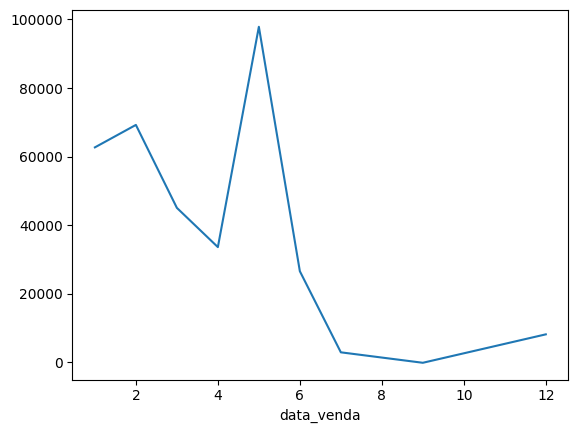

In [34]:
vendas_mes.plot()
plt.show()